The following additional libraries are needed to run this
notebook. Note that running on Colab is experimental, please report a Github
issue if you have any problem.

In [10]:
!pip install d2l==1.0.3


# Calculus
:label:`sec_calculus`

For a long time, how to calculate
the area of a circle remained a mystery.
Then, in Ancient Greece, the mathematician Archimedes
came up with the clever idea
to inscribe a series of polygons
with increasing numbers of vertices
on the inside of a circle
(:numref:`fig_circle_area`).
For a polygon with $n$ vertices,
we obtain $n$ triangles.
The height of each triangle approaches the radius $r$
as we partition the circle more finely.
At the same time, its base approaches $2 \pi r/n$,
since the ratio between arc and secant approaches 1
for a large number of vertices.
Thus, the area of the polygon approaches
$n \cdot r \cdot \frac{1}{2} (2 \pi r/n) = \pi r^2$.

![Finding the area of a circle as a limit procedure.](https://github.com/d2l-ai/d2l-pytorch-colab/blob/master/img/polygon-circle.svg?raw=1)
:label:`fig_circle_area`

This limiting procedure is at the root of both
*differential calculus* and *integral calculus*.
The former can tell us how to increase
or decrease a function's value by
manipulating its arguments.
This comes in handy for the *optimization problems*
that we face in deep learning,
where we repeatedly update our parameters
in order to decrease the loss function.
Optimization addresses how to fit our models to training data,
and calculus is its key prerequisite.
However, do not forget that our ultimate goal
is to perform well on *previously unseen* data.
That problem is called *generalization*
and will be a key focus of other chapters.


In [11]:
%matplotlib inline
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l

## Derivatives and Differentiation

Put simply, a *derivative* is the rate of change
in a function with respect to changes in its arguments.
Derivatives can tell us how rapidly a loss function
would increase or decrease were we
to *increase* or *decrease* each parameter
by an infinitesimally small amount.
Formally, for functions $f: \mathbb{R} \rightarrow \mathbb{R}$,
that map from scalars to scalars,
[**the *derivative* of $f$ at a point $x$ is defined as**]

(**$$f'(x) = \lim_{h \rightarrow 0} \frac{f(x+h) - f(x)}{h}.$$**)
:eqlabel:`eq_derivative`

This term on the right hand side is called a *limit*
and it tells us what happens
to the value of an expression
as a specified variable
approaches a particular value.
This limit tells us what
the ratio between a perturbation $h$
and the change in the function value
$f(x + h) - f(x)$ converges to
as we shrink its size to zero.

When $f'(x)$ exists, $f$ is said
to be *differentiable* at $x$;
and when $f'(x)$ exists for all $x$
on a set, e.g., the interval $[a,b]$,
we say that $f$ is differentiable on this set.
Not all functions are differentiable,
including many that we wish to optimize,
such as accuracy and the area under the
receiving operating characteristic (AUC).
However, because computing the derivative of the loss
is a crucial step in nearly all
algorithms for training deep neural networks,
we often optimize a differentiable *surrogate* instead.


We can interpret the derivative
$f'(x)$
as the *instantaneous* rate of change
of $f(x)$ with respect to $x$.
Let's develop some intuition with an example.
(**Define $u = f(x) = 3x^2-4x$.**)


In [12]:
def f(x):
    return 3 * x ** 2 - 4 * x

[**Setting $x=1$, we see that $\frac{f(x+h) - f(x)}{h}$**] (**approaches $2$
as $h$ approaches $0$.**)
While this experiment lacks
the rigor of a mathematical proof,
we can quickly see that indeed $f'(1) = 2$.


In [13]:
for h in 10.0**np.arange(-1, -6, -1):
    print(f'h={h:.5f}, numerical limit={(f(1+h)-f(1))/h:.5f}')

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


There are several equivalent notational conventions for derivatives.
Given $y = f(x)$, the following expressions are equivalent:

$$f'(x) = y' = \frac{dy}{dx} = \frac{df}{dx} = \frac{d}{dx} f(x) = Df(x) = D_x f(x),$$

where the symbols $\frac{d}{dx}$ and $D$ are *differentiation operators*.
Below, we present the derivatives of some common functions:

$$\begin{aligned} \frac{d}{dx} C & = 0 && \textrm{for any constant $C$} \\ \frac{d}{dx} x^n & = n x^{n-1} && \textrm{for } n \neq 0 \\ \frac{d}{dx} e^x & = e^x \\ \frac{d}{dx} \ln x & = x^{-1}. \end{aligned}$$

Functions composed from differentiable functions
are often themselves differentiable.
The following rules come in handy
for working with compositions
of any differentiable functions
$f$ and $g$, and constant $C$.

$$\begin{aligned} \frac{d}{dx} [C f(x)] & = C \frac{d}{dx} f(x) && \textrm{Constant multiple rule} \\ \frac{d}{dx} [f(x) + g(x)] & = \frac{d}{dx} f(x) + \frac{d}{dx} g(x) && \textrm{Sum rule} \\ \frac{d}{dx} [f(x) g(x)] & = f(x) \frac{d}{dx} g(x) + g(x) \frac{d}{dx} f(x) && \textrm{Product rule} \\ \frac{d}{dx} \frac{f(x)}{g(x)} & = \frac{g(x) \frac{d}{dx} f(x) - f(x) \frac{d}{dx} g(x)}{g^2(x)} && \textrm{Quotient rule} \end{aligned}$$

Using this, we can apply the rules
to find the derivative of $3 x^2 - 4x$ via

$$\frac{d}{dx} [3 x^2 - 4x] = 3 \frac{d}{dx} x^2 - 4 \frac{d}{dx} x = 6x - 4.$$

Plugging in $x = 1$ shows that, indeed,
the derivative equals $2$ at this location.
Note that derivatives tell us
the *slope* of a function
at a particular location.  

## Visualization Utilities

[**We can visualize the slopes of functions using the `matplotlib` library**].
We need to define a few functions.
As its name indicates, `use_svg_display`
tells `matplotlib` to output graphics
in SVG format for crisper images.
The comment `#@save` is a special modifier
that allows us to save any function,
class, or other code block to the `d2l` package
so that we can invoke it later
without repeating the code,
e.g., via `d2l.use_svg_display()`.


In [14]:
def use_svg_display():  #@save
    """Use the svg format to display a plot in Jupyter."""
    backend_inline.set_matplotlib_formats('svg')

Conveniently, we can set figure sizes with `set_figsize`.
Since the import statement `from matplotlib import pyplot as plt`
was marked via `#@save` in the `d2l` package, we can call `d2l.plt`.


In [15]:
def set_figsize(figsize=(3.5, 2.5)):  #@save
    """Set the figure size for matplotlib."""
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize

The `set_axes` function can associate axes
with properties, including labels, ranges,
and scales.


In [17]:
#@save
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Set the axes for matplotlib."""
    axes.set_xlabel(xlabel), axes.set_ylabel(ylabel)
    axes.set_xscale(xscale), axes.set_yscale(yscale)
    axes.set_xlim(xlim),     axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

With these three functions, we can define a `plot` function
to overlay multiple curves.
Much of the code here is just ensuring
that the sizes and shapes of inputs match.


In [18]:
#@save
def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """Plot data points."""

    def has_one_axis(X):  # True if X (tensor or list) has 1 axis
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X): X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)

    set_figsize(figsize)
    if axes is None:
        axes = d2l.plt.gca()
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        axes.plot(x,y,fmt) if len(x) else axes.plot(y,fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

Now we can [**plot the function $u = f(x)$ and its tangent line $y = 2x - 3$ at $x=1$**],
where the coefficient $2$ is the slope of the tangent line.


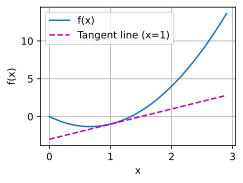

In [19]:
x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

## Partial Derivatives and Gradients
:label:`subsec_calculus-grad`

Thus far, we have been differentiating
functions of just one variable.
In deep learning, we also need to work
with functions of *many* variables.
We briefly introduce notions of the derivative
that apply to such *multivariate* functions.


Let $y = f(x_1, x_2, \ldots, x_n)$ be a function with $n$ variables.
The *partial derivative* of $y$
with respect to its $i^\textrm{th}$ parameter $x_i$ is

$$ \frac{\partial y}{\partial x_i} = \lim_{h \rightarrow 0} \frac{f(x_1, \ldots, x_{i-1}, x_i+h, x_{i+1}, \ldots, x_n) - f(x_1, \ldots, x_i, \ldots, x_n)}{h}.$$


To calculate $\frac{\partial y}{\partial x_i}$,
we can treat $x_1, \ldots, x_{i-1}, x_{i+1}, \ldots, x_n$ as constants
and calculate the derivative of $y$ with respect to $x_i$.
The following notational conventions for partial derivatives
are all common and all mean the same thing:

$$\frac{\partial y}{\partial x_i} = \frac{\partial f}{\partial x_i} = \partial_{x_i} f = \partial_i f = f_{x_i} = f_i = D_i f = D_{x_i} f.$$

We can concatenate partial derivatives
of a multivariate function
with respect to all its variables
to obtain a vector that is called
the *gradient* of the function.
Suppose that the input of function
$f: \mathbb{R}^n \rightarrow \mathbb{R}$
is an $n$-dimensional vector
$\mathbf{x} = [x_1, x_2, \ldots, x_n]^\top$
and the output is a scalar.
The gradient of the function $f$
with respect to $\mathbf{x}$
is a vector of $n$ partial derivatives:

$$\nabla_{\mathbf{x}} f(\mathbf{x}) = \left[\partial_{x_1} f(\mathbf{x}), \partial_{x_2} f(\mathbf{x}), \ldots
\partial_{x_n} f(\mathbf{x})\right]^\top.$$

When there is no ambiguity,
$\nabla_{\mathbf{x}} f(\mathbf{x})$
is typically replaced
by $\nabla f(\mathbf{x})$.
The following rules come in handy
for differentiating multivariate functions:

* For all $\mathbf{A} \in \mathbb{R}^{m \times n}$ we have $\nabla_{\mathbf{x}} \mathbf{A} \mathbf{x} = \mathbf{A}^\top$ and $\nabla_{\mathbf{x}} \mathbf{x}^\top \mathbf{A}  = \mathbf{A}$.
* For square matrices $\mathbf{A} \in \mathbb{R}^{n \times n}$ we have that $\nabla_{\mathbf{x}} \mathbf{x}^\top \mathbf{A} \mathbf{x}  = (\mathbf{A} + \mathbf{A}^\top)\mathbf{x}$ and in particular
$\nabla_{\mathbf{x}} \|\mathbf{x} \|^2 = \nabla_{\mathbf{x}} \mathbf{x}^\top \mathbf{x} = 2\mathbf{x}$.

Similarly, for any matrix $\mathbf{X}$,
we have $\nabla_{\mathbf{X}} \|\mathbf{X} \|_\textrm{F}^2 = 2\mathbf{X}$.



## Chain Rule

In deep learning, the gradients of concern
are often difficult to calculate
because we are working with
deeply nested functions
(of functions (of functions...)).
Fortunately, the *chain rule* takes care of this.
Returning to functions of a single variable,
suppose that $y = f(g(x))$
and that the underlying functions
$y=f(u)$ and $u=g(x)$
are both differentiable.
The chain rule states that


$$\frac{dy}{dx} = \frac{dy}{du} \frac{du}{dx}.$$



Turning back to multivariate functions,
suppose that $y = f(\mathbf{u})$ has variables
$u_1, u_2, \ldots, u_m$,
where each $u_i = g_i(\mathbf{x})$
has variables $x_1, x_2, \ldots, x_n$,
i.e.,  $\mathbf{u} = g(\mathbf{x})$.
Then the chain rule states that

$$\frac{\partial y}{\partial x_{i}} = \frac{\partial y}{\partial u_{1}} \frac{\partial u_{1}}{\partial x_{i}} + \frac{\partial y}{\partial u_{2}} \frac{\partial u_{2}}{\partial x_{i}} + \ldots + \frac{\partial y}{\partial u_{m}} \frac{\partial u_{m}}{\partial x_{i}} \ \textrm{ and so } \ \nabla_{\mathbf{x}} y =  \mathbf{A} \nabla_{\mathbf{u}} y,$$

where $\mathbf{A} \in \mathbb{R}^{n \times m}$ is a *matrix*
that contains the derivative of vector $\mathbf{u}$
with respect to vector $\mathbf{x}$.
Thus, evaluating the gradient requires
computing a vector--matrix product.
This is one of the key reasons why linear algebra
is such an integral building block
in building deep learning systems.



## Discussion

While we have just scratched the surface of a deep topic,
a number of concepts already come into focus:
first, the composition rules for differentiation
can be applied routinely, enabling
us to compute gradients *automatically*.
This task requires no creativity and thus
we can focus our cognitive powers elsewhere.
Second, computing the derivatives of vector-valued functions
requires us to multiply matrices as we trace
the dependency graph of variables from output to input.
In particular, this graph is traversed in a *forward* direction
when we evaluate a function
and in a *backwards* direction
when we compute gradients.
Later chapters will formally introduce backpropagation,
a computational procedure for applying the chain rule.

From the viewpoint of optimization, gradients allow us
to determine how to move the parameters of a model
in order to lower the loss,
and each step of the optimization algorithms used
throughout this book will require calculating the gradient.

## Exercises

1. So far we took the rules for derivatives for granted.
   Using the definition and limits prove the properties
   for (i) $f(x) = c$, (ii) $f(x) = x^n$, (iii) $f(x) = e^x$ and (iv) $f(x) = \log x$.
1. In the same vein, prove the product, sum, and quotient rule from first principles.
1. Prove that the constant multiple rule follows as a special case of the product rule.
1. Calculate the derivative of $f(x) = x^x$.
1. What does it mean that $f'(x) = 0$ for some $x$?
   Give an example of a function $f$
   and a location $x$ for which this might hold.
1. Plot the function $y = f(x) = x^3 - \frac{1}{x}$
   and plot its tangent line at $x = 1$.
1. Find the gradient of the function
   $f(\mathbf{x}) = 3x_1^2 + 5e^{x_2}$.
1. What is the gradient of the function
   $f(\mathbf{x}) = \|\mathbf{x}\|_2$? What happens for $\mathbf{x} = \mathbf{0}$?
1. Can you write out the chain rule for the case
   where $u = f(x, y, z)$ and $x = x(a, b)$, $y = y(a, b)$, and $z = z(a, b)$?
1. Given a function $f(x)$ that is invertible,
   compute the derivative of its inverse $f^{-1}(x)$.
   Here we have that $f^{-1}(f(x)) = x$ and conversely $f(f^{-1}(y)) = y$.
   Hint: use these properties in your derivation.


[Discussions](https://discuss.d2l.ai/t/33)


## Solution

Let's work through the exercises in order, explaining each result before checking it with code.

### 1. Derivatives from the Definition

Start with the difference quotient

$$f'(x)=\lim_{h\to0}\frac{f(x+h)-f(x)}{h}.$$

For **a constant**, $f(x)=c$, the numerator is $c-c=0$
for every nonzero $h$, so $f'(x)=0$.

For **a positive integer power**, the binomial theorem gives

$$(x+h)^n-x^n=nx^{n-1}h+\binom{n}{2}x^{n-2}h^2+\cdots+h^n.$$

After division by $h$, all terms except the first tend to zero.
Hence $(x^n)'=nx^{n-1}$. The case $n=0$ is constant.
For a negative integer $n=-m$, use

$$\frac{(x+h)^{-m}-x^{-m}}{h}
=-\frac{(x+h)^m-x^m}{h\,x^m(x+h)^m}$$

for $x\ne0$, and the positive-integer result yields $-mx^{-m-1}$.
For arbitrary real $n$, on $x>0$, write $x^n=e^{n\log x}$;
the exponential and logarithm results below, with the chain rule,
give the same formula.

For **the exponential**, use $e^{x+h}=e^xe^h$.
The series definition gives

$$\frac{e^h-1}{h}=1+\frac{h}{2!}+\frac{h^2}{3!}+\cdots\longrightarrow1.$$

Indeed, for $|h|\le1$, the absolute value of the remainder is bounded
by $|h|\sum_{k=2}^\infty1/k!$, which tends to zero.
Multiplying by $e^x$ proves $(e^x)'=e^x$.

For **the logarithm**, take $x>0$ and put $t=\log(1+h/x)$.
As $h\to0$, continuity of the logarithm gives $t\to0$,
and $h=x(e^t-1)$. Thus

$$\frac{\log(x+h)-\log x}{h}
=\frac1x\frac{t}{e^t-1}\longrightarrow\frac1x.$$

The last limit follows from the exponential limit just proved.
Let's check these formulas numerically. Finite differences provide a check,
while the limit arguments above supply the proofs.

In [20]:
import numpy as np

def central_diff(function, x, h=1e-6):
    return (function(x + h) - function(x - h)) / (2 * h)

examples = [
    ("constant", lambda x: 7.0, 2.0, 0.0),
    ("fourth power", lambda x: x**4, 2.0, 32.0),
    ("exponential", np.exp, 1.0, np.e),
    ("logarithm", np.log, 2.0, 0.5),
]
for name, function, point, expected in examples:
    estimate = central_diff(function, point)
    print(name, "numerical:", round(estimate, 8), "expected:", round(expected, 8),
          "agree:", np.isclose(estimate, expected))

constant numerical: 0.0 expected: 0.0 agree: True
fourth power numerical: 32.0 expected: 32.0 agree: True
exponential numerical: 2.71828183 expected: 2.71828183 agree: True
logarithm numerical: 0.5 expected: 0.5 agree: True


### 2. Sum, Product, and Quotient Rules from First Principles

Assume $f$ and $g$ are differentiable at $x$.
For a sum, split the difference quotient:

$$\frac{(f+g)(x+h)-(f+g)(x)}{h}
=\frac{f(x+h)-f(x)}h+\frac{g(x+h)-g(x)}h.$$

Taking limits gives $(f+g)'=f'+g'$.

For a product, add and subtract $f(x+h)g(x)$ in the numerator:

$$\frac{f(x+h)g(x+h)-f(x)g(x)}h
=f(x+h)\frac{g(x+h)-g(x)}h
+g(x)\frac{f(x+h)-f(x)}h.$$

Differentiability implies continuity, so $f(x+h)\to f(x)$.
The limit is $fg'+gf'$.

For a quotient, assume $g(x)\ne0$.
Continuity ensures $g(x+h)\ne0$ for sufficiently small $h$.
Putting the two fractions over a common denominator gives

$$\frac{f(x+h)/g(x+h)-f(x)/g(x)}h
=\frac{g(x)\,[f(x+h)-f(x)]/h
-f(x)\,[g(x+h)-g(x)]/h}{g(x+h)g(x)}.$$

Taking limits directly proves

$$\left(\frac fg\right)'=\frac{gf'-fg'}{g^2}.$$

Let's check all three rules with $f(x)=x^2$ and $g(x)=e^x$ at $x=1$.

In [21]:
point = 1.0
checks = [
    ("sum", lambda x: x**2 + np.exp(x), 2 + np.e),
    ("product", lambda x: x**2 * np.exp(x), 3 * np.e),
    ("quotient", lambda x: x**2 / np.exp(x), 1 / np.e),
]
for name, function, expected in checks:
    estimate = central_diff(function, point)
    print(name, "numerical:", estimate, "formula:", expected,
          "agree:", np.isclose(estimate, expected))

sum numerical: 4.718281828353099 formula: 4.718281828459045 agree: True
product numerical: 8.154845485108808 formula: 8.154845485377136 agree: True
quotient numerical: 0.36787944118765736 formula: 0.36787944117144233 agree: True


### 3. The Constant Multiple Rule

Treat the constant $c$ as a function whose derivative is zero.
The product rule then gives

$$\frac{d}{dx}[cf(x)]=c'f(x)+cf'(x)=cf'(x).$$

For example, $(3x^2)'=3(2x)=6x$.
At $x=2$, the derivative is $12$.

In [22]:
print("Numerical derivative:", central_diff(lambda x: 3 * x**2, 2.0))
print("Expected derivative:", 6 * 2.0)

Numerical derivative: 12.000000000789157
Expected derivative: 12.0


### 4. Differentiating $x^x$

For a real-valued function on $x>0$, write $y=x^x=e^{x\log x}$.
Applying the chain rule followed by the product rule gives

$$y'=e^{x\log x}\left(\log x+x\frac1x\right)
=x^x(\log x+1).$$

Both the base and exponent vary with $x$,
so treating the exponent as a constant would miss a term.

In [23]:
point = 2.0
expected = point**point * (np.log(point) + 1)
print("Numerical derivative:", central_diff(lambda x: x**x, point))
print("Formula:", expected)

Numerical derivative: 6.772588722503414
Formula: 6.772588722239782


### 5. Understanding a Zero Derivative

If $f'(x_0)=0$, the graph has a horizontal tangent at $x_0$.
Such a point is called *stationary*.
It need not be a minimum or maximum.

At $x_0=0$, $f(x)=x^2$ has a minimum,
$f(x)=-x^2$ has a maximum, and $f(x)=x^3$ has neither.
All three derivatives are zero there.
Further information about nearby values is needed to distinguish these cases.

In [24]:
for name, function in [("minimum: x^2", lambda x: x**2),
                       ("maximum: -x^2", lambda x: -x**2),
                       ("neither: x^3", lambda x: x**3)]:
    print(name, "slope near zero:", central_diff(function, 0.0))

minimum: x^2 slope near zero: 0.0
maximum: -x^2 slope near zero: 0.0
neither: x^3 slope near zero: 1e-12


### 6. Plotting a Curve and Its Tangent

For $f(x)=x^3-1/x$, where $x\ne0$,

$$f'(x)=3x^2+\frac1{x^2}.$$

At $x=1$, $f(1)=0$ and $f'(1)=4$.
The tangent line is therefore

$$y=f(1)+f'(1)(x-1)=4x-4.$$

The curve has a singularity at zero.
We plot its negative and positive branches separately
so the plot does not connect across this missing point.
The second panel zooms in on the tangent point.

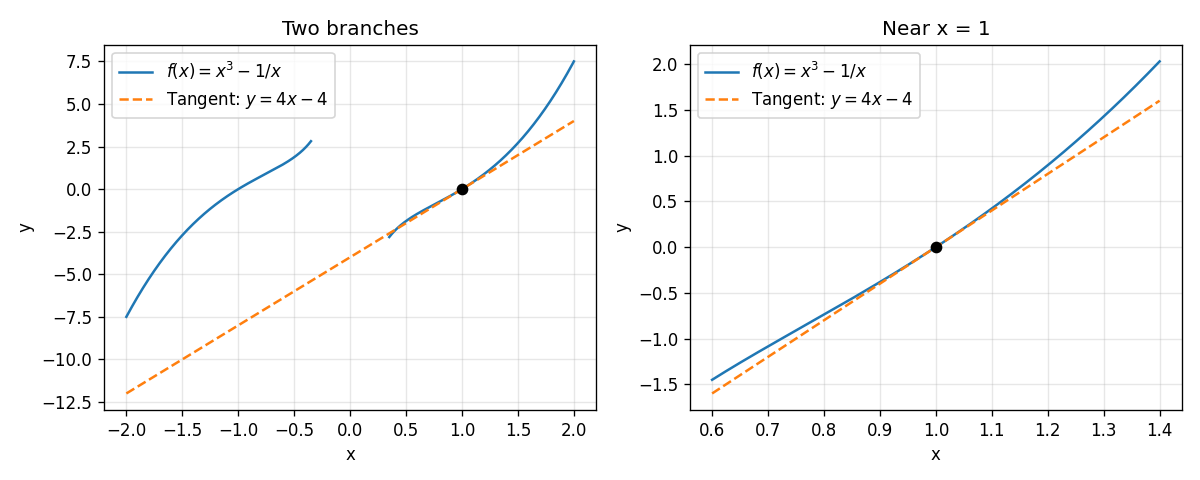

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for index, ax in enumerate(axes):
    intervals = [(-2.0, -0.35), (0.35, 2.0)] if index == 0 else [(0.6, 1.4)]
    for branch, (left, right) in enumerate(intervals):
        points = np.linspace(left, right, 300)
        ax.plot(points, points**3 - 1 / points,
                color="tab:blue", label=r"$f(x)=x^3-1/x$" if branch == 0 else None)
    points = np.linspace(-2, 2, 300) if index == 0 else np.linspace(0.6, 1.4, 300)
    ax.plot(points, 4 * points - 4, "--", color="tab:orange", label=r"Tangent: $y=4x-4$")
    ax.scatter([1], [0], color="black", zorder=3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Two branches" if index == 0 else "Near x = 1")
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
plt.show()

### 7. The Gradient of a Two-Variable Function

For $f(\mathbf{x})=3x_1^2+5e^{x_2}$,
hold $x_2$ fixed when differentiating with respect to $x_1$,
and hold $x_1$ fixed when differentiating with respect to $x_2$.
This gives

$$\nabla f(\mathbf{x})=
\begin{bmatrix}6x_1\\5e^{x_2}\end{bmatrix}.$$

At $(x_1,x_2)=(2,0)$, the gradient is $(12,5)^\top$.
Let's verify each component by perturbing only its own coordinate.

In [26]:
def multivariate_f(x):
    return 3 * x[0]**2 + 5 * np.exp(x[1])

point = np.array([2., 0.])
h = 1e-6
numerical = np.array([
    (multivariate_f(point + h * direction) - multivariate_f(point - h * direction)) / (2 * h)
    for direction in np.eye(2)
])
expected = np.array([6 * point[0], 5 * np.exp(point[1])])
print("Numerical gradient:", numerical)
print("Formula:", expected)
print("Agree:", np.allclose(numerical, expected))

Numerical gradient: [12.  5.]
Formula: [12.  5.]
Agree: True


### 8. The Gradient of the Euclidean Norm

For $\mathbf{x}\ne\mathbf0$,

$$\|\mathbf{x}\|_2=\left(\sum_i x_i^2\right)^{1/2},
\qquad \partial_{x_i}\|\mathbf{x}\|_2
=\frac12\left(\sum_jx_j^2\right)^{-1/2}(2x_i).$$

Thus $\nabla\|\mathbf{x}\|_2=\mathbf{x}/\|\mathbf{x}\|_2$.
For $(3,4)^\top$, the gradient is $(0.6,0.8)^\top$.

At the origin, a gradient does not exist.
Restricting the function to the first coordinate axis gives $|t|$.
Its difference quotient at zero is $1$ for $t>0$ and $-1$ for $t<0$,
so even that partial derivative has no two-sided limit.
Notice that the denominator in the left-hand quotient must be negative.

In [27]:
point = np.array([3., 4.])
print("Gradient away from zero:", point / np.linalg.norm(point))
h = 1e-6
right = (np.linalg.norm([h, 0.]) - 0) / h
left = (np.linalg.norm([-h, 0.]) - 0) / (-h)
print("Right slope at zero:", right)
print("Left slope at zero:", left)

Gradient away from zero: [0.6 0.8]
Right slope at zero: 1.0
Left slope at zero: -1.0


### 9. A Multivariable Chain Rule

The variables $a$ and $b$ each affect $u$ through three paths:
through $x$, through $y$, and through $z$.
Multiply the local derivatives along each path and add the contributions:

$$\frac{\partial u}{\partial a}
=f_x x_a+f_y y_a+f_z z_a,\qquad
\frac{\partial u}{\partial b}
=f_x x_b+f_y y_b+f_z z_b.$$

The derivatives of $f$ are evaluated at
$(x(a,b),y(a,b),z(a,b))$.
Equivalently, if $J$ is the $3\times2$ Jacobian of $(x,y,z)$
with respect to $(a,b)$, then $\nabla_{(a,b)}u=J^\top\nabla_{(x,y,z)}f$.

For a concrete example, take $f=xy+z^2$,
$x=a+b$, $y=ab$, and $z=a-b$.
At $(a,b)=(2,3)$, we have $(x,y,z)=(5,6,-1)$.
The formulas give $u_a=6+5(3)-2=19$
and $u_b=6+5(2)+2=18$.

In [28]:
a, b = 2., 3.
x, y, z = a + b, a * b, a - b
fx, fy, fz = y, x, 2 * z
chain_gradient = np.array([fx + fy * b + fz, fx + fy * a - fz])
def composed(a, b):
    return (a + b) * (a * b) + (a - b)**2
numerical = np.array([central_diff(lambda t: composed(t, b), a),
                      central_diff(lambda t: composed(a, t), b)])
print("Chain-rule gradient:", chain_gradient)
print("Numerical gradient:", numerical)
print("Agree:", np.allclose(chain_gradient, numerical))

Chain-rule gradient: [19. 18.]
Numerical gradient: [19. 18.]
Agree: True


### 10. The Derivative of an Inverse

Let $g=f^{-1}$. Differentiating $f(g(y))=y$ gives

$$f'(g(y))g'(y)=1,
\qquad g'(y)=\frac1{f'(g(y))}.$$

This formula applies where the inverse is differentiable
and the denominator is nonzero. For example,
if $f$ is continuously differentiable near a point with $f'\ne0$,
it has a differentiable local inverse there.
Invertibility alone does not guarantee a finite inverse derivative:
$f(x)=x^3$ is invertible, but its inverse has no finite derivative at zero.

For $f(x)=e^x$, the inverse is $g(y)=\log y$ on $y>0$.
The formula gives $g'(y)=1/e^{\log y}=1/y$.

In [29]:
point = 2.0
inverse_formula = 1 / np.exp(np.log(point))
print("Inverse derivative formula:", inverse_formula)
print("Numerical derivative of log:", central_diff(np.log, point))

Inverse derivative formula: 0.5
Numerical derivative of log: 0.5000000000143778
